## Setup

In [3]:
import os
os.environ['MPLBACKEND'] = 'inline'

# Keep kernel alive - run this if kernel feels sluggish
import ipykernel
print("Kernel active:", ipykernel.__version__)

Kernel active: 6.31.0


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import missingno as msno
import re

## Load Dataset

In [8]:
rdf = pd.read_csv(r'../raw_data/ulta_clean_blush.csv', encoding='utf-8-sig')
rdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 1514 entries, 0 to 1513
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   shade_url       1514 non-null   str    
 1   brand           1514 non-null   str    
 2   product_name    1514 non-null   str    
 3   shade           1514 non-null   str    
 4   swatch_img_url  1514 non-null   str    
 5   swatch_alt      1514 non-null   str    
 6   description     1148 non-null   str    
 7   price           1514 non-null   float64
 8   currency        1514 non-null   str    
 9   size            1348 non-null   str    
dtypes: float64(1), str(9)
memory usage: 118.4 KB


## Exploratory Data Analysis (EDA)

In [11]:
def explore_dataframe(df, name="Dataset"):
    """
    Performs a comprehensive initial scan of a pandas DataFrame.
    """
    print(f" {'='*10} Exploring: {name} {'='*10}\n")
    
    # 1. Dimensions and Basics
    print("### 1. Shape & Memory")
    print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
    print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")
    
    # 2. Data Types and Nulls
    print("### 2. Data Types and Missing Values")
    info_df = pd.DataFrame({
        'Data Type': df.dtypes,
        'Null Count': df.isnull().sum(),
        'Null %': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique Values': df.nunique()
    })
    print(info_df)
    print("\n")

    # 3. Duplicate Check
    print("### 3. Duplicate Rows")
    dup_count = df.duplicated().sum()
    dup_pct = (dup_count / len(df) * 100).round(2)
    print(f"Duplicate Rows: {dup_count} ({dup_pct}%)")
    if dup_count > 0:
        print("💡 Pro-tip: Use `df[df.duplicated(keep=False)]` to see all versions of duplicates.")
    print("\n")
    
    # 4. Descriptive Statistics (Numerical)
    if not df.select_dtypes(include=['number']).empty:
        print("### 4. Numerical Summary")
        print(df.describe().T.round(2))
        print("\n")
    
    # 5. Descriptive Statistics (Categorical/Object)
    if not df.select_dtypes(include=['object', 'category']).empty:
        print("### 5. Categorical Summary")
        print(df.describe(include=['object', 'category']).T)
        print("\n")
        
    # 6. The "Sneak Peek"
    print("### 6. First 5 Rows")
    display(df.head()) # Use display() for pretty Jupyter formatting, or print() otherwise
    print("-" * 40)

In [12]:
explore_dataframe(rdf, "My Survey Data")

 ========== Exploring: My Survey Data ==========

### 1. Shape & Memory
Rows: 1514 | Columns: 10
Memory Usage: 1.02 MB

### 2. Data Types and Missing Values
               Data Type  Null Count  Null %  Unique Values
shade_url            str           0    0.00           1514
brand                str           0    0.00             90
product_name         str           0    0.00            252
shade                str           0    0.00           1397
swatch_img_url       str           0    0.00           1514
swatch_alt           str           0    0.00           1514
description          str         366   24.17            873
price            float64           0    0.00             69
currency             str           0    0.00              1
size                 str         166   10.96             64


### 3. Duplicate Rows
Duplicate Rows: 0 (0.0%)


### 4. Numerical Summary
        count   mean    std  min   25%   50%   75%   max
price  1514.0  24.67  11.45  4.0  15.5  26.0  34.0

C:\Users\thaop\AppData\Local\Temp\ipykernel_7092\1509044483.py:39: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  if not df.select_dtypes(include=['object', 'category']).empty:
C:\Users\thaop\AppData\Local\Temp\ipykernel_7092\1509044483.py:41: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/use

,shade_url,brand,product_name,shade,swatch_img_url,swatch_alt,description,price,currency,size
0,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Bubblegum Pop,https://media.ultainc.com/i/ulta/2634527_sw?im...,Bubblegum Pop Trublend Skin Enhancer Balm Blus...,"cool, bright pink",12.99,USD,0.21 oz
1,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Candied Strawberry,https://media.ultainc.com/i/ulta/2652760_sw?im...,Candied Strawberry Trublend Skin Enhancer Balm...,bright red,12.99,USD,0.21 oz
2,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Midnight Plum,https://media.ultainc.com/i/ulta/2652756_sw?im...,Midnight Plum Trublend Skin Enhancer Balm Blus...,deep berry,12.99,USD,0.21 oz
3,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Nude Flush,https://media.ultainc.com/i/ulta/2634526_sw?im...,Nude Flush Trublend Skin Enhancer Balm Blush S...,nude pink,12.99,USD,0.21 oz
4,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Pink Sprinkle,https://media.ultainc.com/i/ulta/2652758_sw?im...,Pink Sprinkle Trublend Skin Enhancer Balm Blus...,warm pink,12.99,USD,0.21 oz


----------------------------------------


In [7]:
rdf['brand'].value_counts().index

Index(['MAC', 'Tarte', 'fwee', 'NUDESTIX', 'ULTA Beauty Collection', 'NARS',
       'Palladio Beauty', 'Revolution Beauty', 'Benefit Cosmetics',
       'bareMinerals', 'Juvia's Place', 'BOBBI BROWN', 'e.l.f. Cosmetics',
       'Charlotte Tilbury', 'Milani', 'Clinique', 'CHANEL', 'ColourPop',
       'Maybelline', 'Essence', 'r.e.m. beauty', 'MILK MAKEUP', 'Rare Beauty',
       'Too Faced', 'NYX Professional Makeup', 'jane iredale', 'J.Cat Beauty',
       'L.A. Girl', 'KYLIE COSMETICS', 'Laura Mercier', 'about-face',
       'RMS Beauty', 'Lancôme', 'ILIA', 'PAT McGRATH LABS', 'CoverGirl',
       'Pixi', 'KIKO Milano', 'Live Tinted', 'Dior', 'HOURGLASS',
       'FENTY BEAUTY by Rihanna', 'Made By Mitchell', 'DIBS Beauty', 'L'Oréal',
       'Flower Knows', 'Sigma Beauty', 'NATASHA DENONA', 'Morphe',
       'Jungsaemmool', 'Polite Society', 'Wet n Wild', 'Stila', 'LORAC',
       'Persona', 'IT Cosmetics', 'Jouer Cosmetics', 'PÃÂR Minerals',
       'Estée Lauder', 'Kaja', 'Revlon', 'Ere Pe

In [10]:
rdf[rdf['size'].isnull()].head() # display top 5 rows where there are missing value in `size`

,shade_url,brand,product_name,shade,swatch_img_url,swatch_alt,description,price,currency,size
22,https://www.ulta.com/p/play-daze-airy-soft-mat...,Benefit Cosmetics,Play Daze Airy Soft Matte Liquid Blush,Apricotta,https://media.ultainc.com/i/ulta/2653178_sw?im...,Apricotta Play Daze Airy Soft Matte Liquid Blush,warm apricotÃ,34.0,USD,NaN
23,https://www.ulta.com/p/play-daze-airy-soft-mat...,Benefit Cosmetics,Play Daze Airy Soft Matte Liquid Blush,Willa,https://media.ultainc.com/i/ulta/2653179_sw?im...,Willa Play Daze Airy Soft Matte Liquid Blush,soft neutral-roseÃ,34.0,USD,NaN
24,https://www.ulta.com/p/play-daze-airy-soft-mat...,Benefit Cosmetics,Play Daze Airy Soft Matte Liquid Blush,Starlaa,https://media.ultainc.com/i/ulta/2653180_sw?im...,Starlaa Play Daze Airy Soft Matte Liquid Blush,rosy bronzeÃ,34.0,USD,NaN
25,https://www.ulta.com/p/play-daze-airy-soft-mat...,Benefit Cosmetics,Play Daze Airy Soft Matte Liquid Blush,Chili,https://media.ultainc.com/i/ulta/2653181_sw?im...,Chili Play Daze Airy Soft Matte Liquid Blush,coral-orangeÃ,34.0,USD,NaN
26,https://www.ulta.com/p/play-daze-airy-soft-mat...,Benefit Cosmetics,Play Daze Airy Soft Matte Liquid Blush,Berri,https://media.ultainc.com/i/ulta/2653182_sw?im...,Berri Play Daze Airy Soft Matte Liquid Blush,blackberryÃ,34.0,USD,NaN


In [45]:
null_size = rdf[rdf['size'].isnull()] # rows of missing values of size
null_size.info()

<class 'pandas.DataFrame'>
Index: 71 entries, 419 to 1436
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   shade_url       71 non-null     str    
 1   brand           71 non-null     str    
 2   product_name    71 non-null     str    
 3   shade           71 non-null     str    
 4   swatch_img_url  71 non-null     str    
 5   swatch_alt      71 non-null     str    
 6   description     28 non-null     str    
 7   price           71 non-null     float64
 8   currency        71 non-null     str    
 9   size            0 non-null      str    
dtypes: float64(1), str(9)
memory usage: 6.1 KB


In [11]:
null_size['brand'].value_counts().index

Index(['Palladio Beauty', 'Revolution Beauty', 'Juvia's Place',
       'Benefit Cosmetics', 'jane iredale', 'Tarte', 'J.Cat Beauty', 'Lancôme',
       'Estée Lauder', 'Made By Mitchell', 'Live Tinted', 'Morphe',
       'Anastasia Beverly Hills', 'Wet n Wild', 'Revlon', 'Essence',
       'L.A. Girl', 'NARS', 'MAC', 'about-face', 'ColourPop', 'Persona'],
      dtype='str', name='brand')

In [27]:
null_size['brand'].value_counts().values

array([35, 27, 18, 10,  9,  7,  7,  6,  6,  6,  5,  5,  4,  4,  3,  3,  3,
        2,  2,  2,  1,  1])

In [18]:
null_size[['brand','product_name']].value_counts() # 0.2 oz

brand                    product_name                                       
Juvia's Place            Blushed Cream Blush                                    8
Palladio Beauty          Matte Blush                                            8
Revolution Beauty        Superdewy Liquid Blush Burst                           8
Juvia's Place            Blushed Liquid Blushlighter                            7
jane iredale             PurePressed Blush                                      7
J.Cat Beauty             Blush-Mallow Soft Blusher                              7
Palladio Beauty          Jelly Tint - 2-in-1 Lip & Cheek Tint Stain             6
Lancôme                  Skin Idôle Juicy Liquid Blush                          6
Estée Lauder             Futurist Blushmaker Dewy Cheek TintÃÂ Liquid Blush    6
Tarte                    Macaron Blush & Glow Duo                               6
Revolution Beauty        Bouncy Blur Blush                                      6
Palladio Beauty      

### Data Visualization

#### Missing Values
- Data Completeness between Non-Null and Null values
- Matrix: Display data density

In [ ]:
def plot_missing_values(df):
    # 1. Prepare Data
    total_rows = len(df)
    null_counts = df.isnull().sum()
    present_counts = total_rows - null_counts
    
    plot_df = pd.DataFrame({
        'Column': df.columns,
        'Present': present_counts,
        'Missing': null_counts
    }).sort_values(by='Missing', ascending=False)

    # 2. Setup Plot
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(14, 8))

    # 3. Create Stacked Bars
    bar_present = ax.bar(plot_df['Column'], plot_df['Present'], 
                         color='#2ecc71', label='Present (Non-Null)')
    
    bar_missing = ax.bar(plot_df['Column'], plot_df['Missing'], 
                         bottom=plot_df['Present'], color='#e74c3c', label='Missing (Null)')

    # 4. Generate Custom Labels (Count + Percentage)
    # Format: "Count (Percent%)"
    # We use \n for a line break to keep it tidy inside the bars
    present_labels = [
        f'{int(c)}\n({(c/total_rows*100):.1f}%)' if c > 0 else '' 
        for c in plot_df['Present']
    ]
    
    missing_labels = [
        f'{int(c)}\n({(c/total_rows*100):.1f}%)' if c > 0 else '' 
        for c in plot_df['Missing']
    ]

    # 5. Apply Labels to Bars
    ax.bar_label(bar_present, labels=present_labels, label_type='center', 
                 color='black', fontweight='bold', fontsize=9)
    
    ax.bar_label(bar_missing, labels=missing_labels, label_type='center', 
                 color='black', fontweight='bold', fontsize=9)

    # 6. Formatting & Final Touches
    ax.set_title('Data Completeness: Count and Percentage per Column', fontsize=16, pad=20)
    ax.set_ylabel('Number of Records', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Move legend outside the plot area
    ax.legend(title="Status", bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()


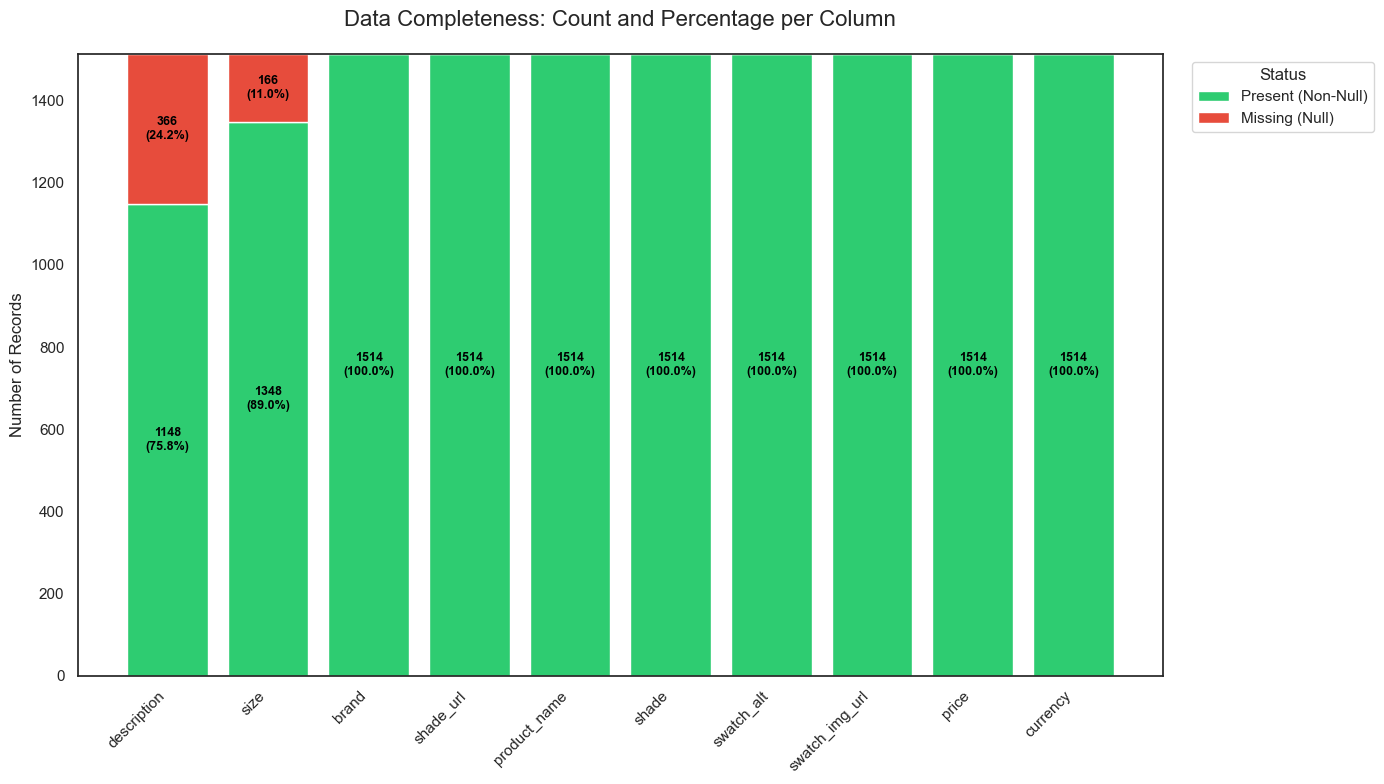

In [12]:
plot_missing_values(rdf)

**Observation**: Data Completeness
- There're 10 fields/columns in the dataset, 8/10 have no missing value and 2/10 have missing values, which are `size` and `description`.
    - The missing rows of `size` is 116/1514, which is 11% data.
    - The missing rows of `description` is 366/1514, which is most a quater (24.2%) of the data.

<Axes: >

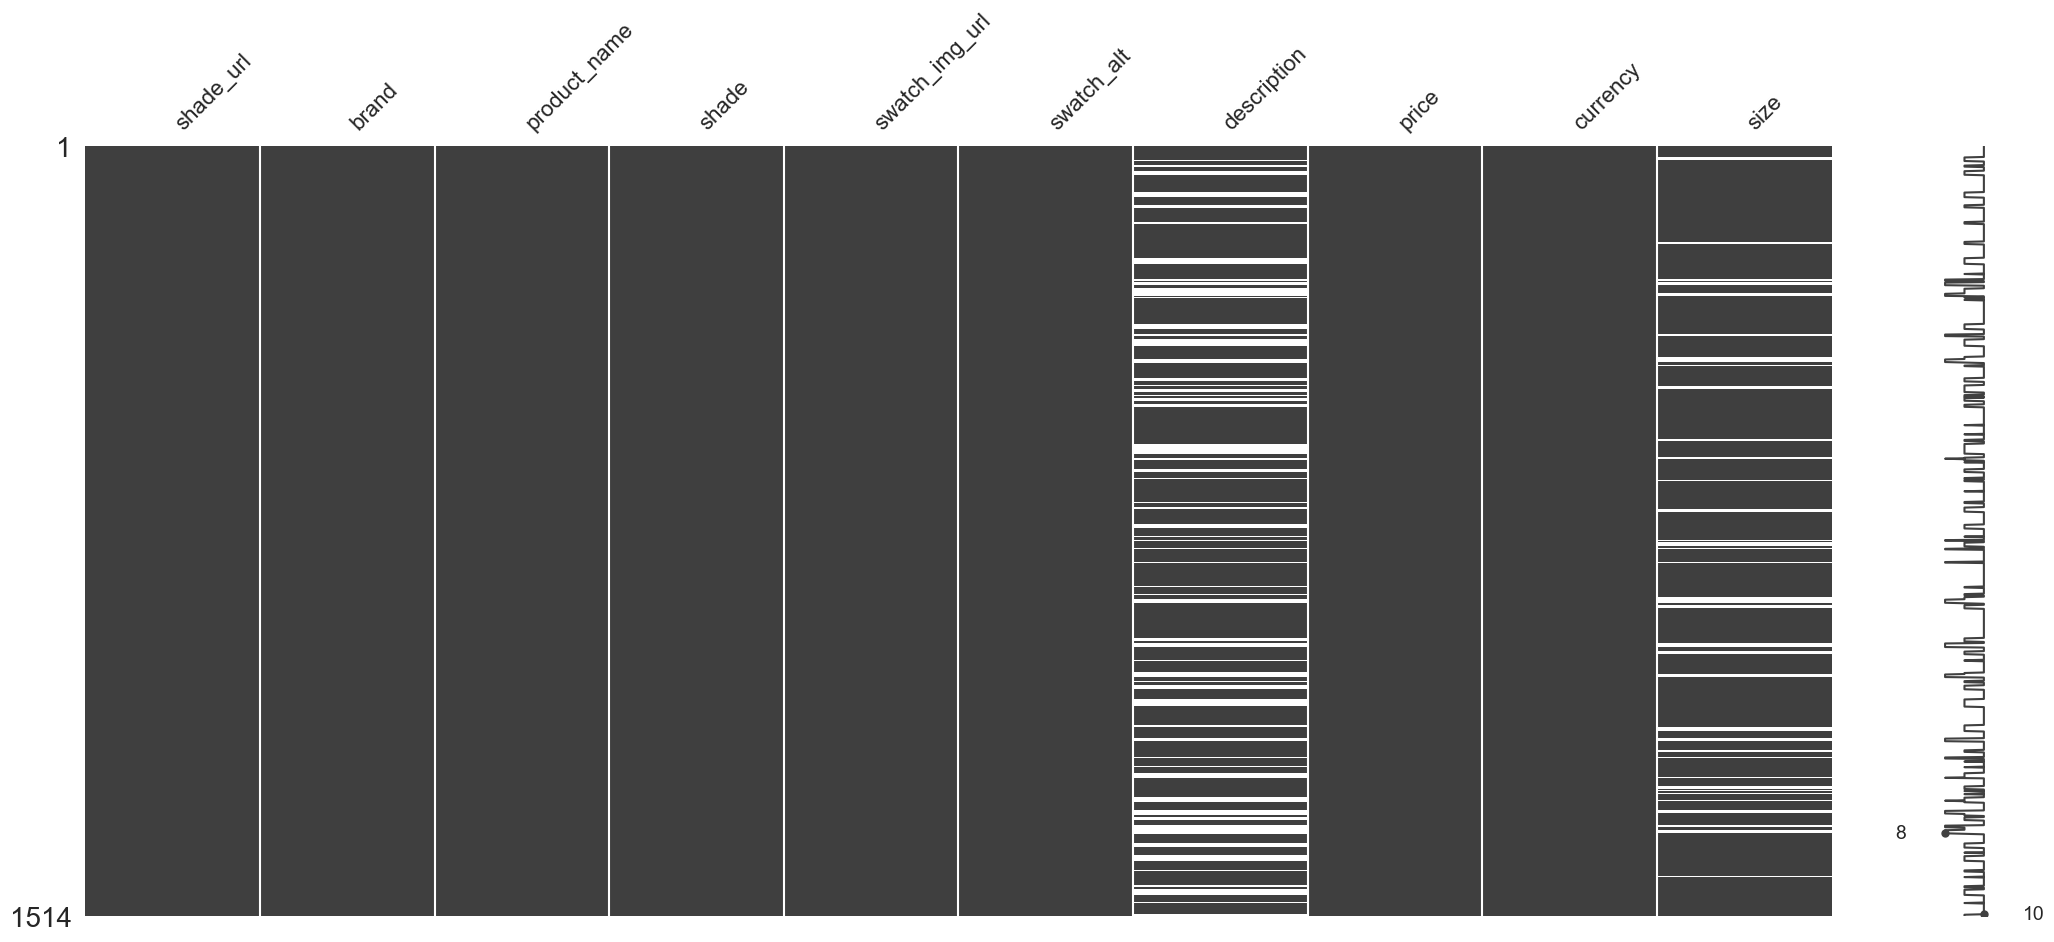

In [21]:
# Matrix Plot: you might need to install missingo
## !pip install missingno
# 1. Bar Chart: A clean, simple summary of nulls
# msno.bar(rdf, color=(0.2, 0.4, 0.6), fontsize=12)

# 2. Matrix: Shows the location of missing values (the "barcode" view)
msno.matrix(rdf)

**Observation:** 
The Matrix shows the location of missing values with the white color indicates the missing gaps

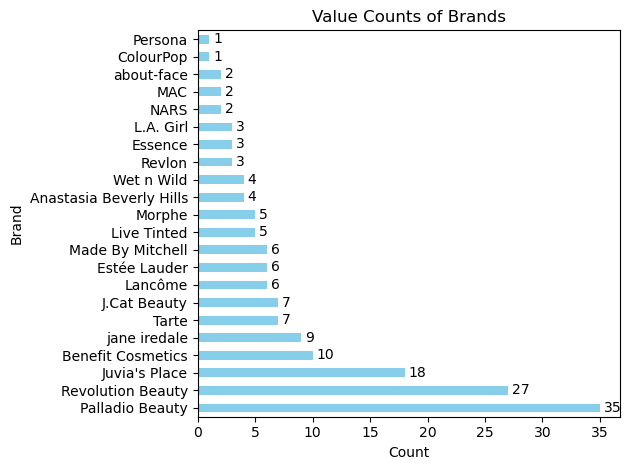

In [14]:
# 1. Assign the plot to 'ax'
ax = null_size['brand'].value_counts().plot(kind='barh', color='skyblue')

# 2. Use bar_label on the first container (the bars)
ax.bar_label(ax.containers[0], padding=3)

# 3. Clean up labels
plt.ylabel('Brand')
plt.xlabel('Count')
plt.title('Value Counts of Brands')
plt.tight_layout() # Prevents labels from getting cut off
plt.show()

In [15]:
null_size['brand'].value_counts().index.name

'brand'

<Axes: xlabel='product_name'>

c:\Users\thaop\anaconda3\envs\pigment\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\thaop\anaconda3\envs\pigment\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


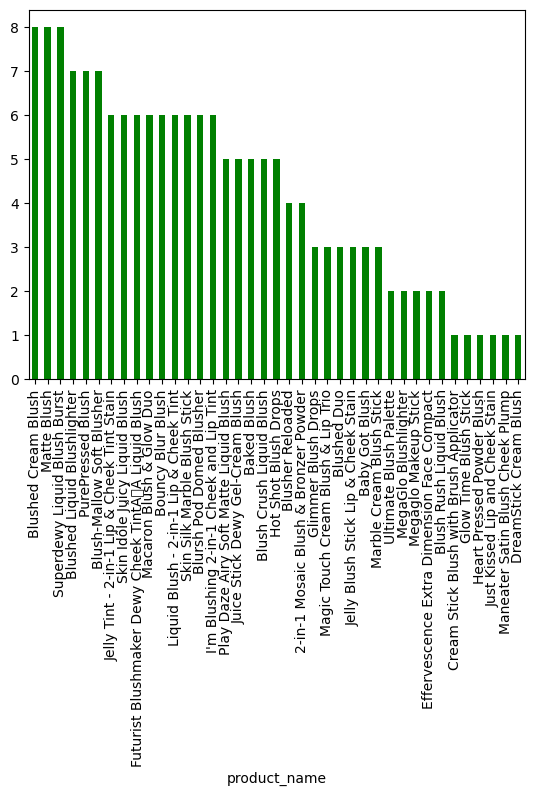

In [ ]:
null_size['product_name'].value_counts().plot(kind='bar', color='green') 



## Data Cleaning
- Drop `currency` column
- Handle Null values of `size`
- Parse `size` column to get the value and unit of each product/row

### Handle Encoding
- Fix Encoding Issues with `power_clean()`

**Display Encoding Issues**

In [5]:
## display the encoding
rdf.loc[rdf['product_name'].str.contains('Â', 'Ã', na=False), ['brand','product_name', 'shade_url']]

,brand,product_name,shade_url
472,Estée Lauder,Futurist Blushmaker Dewy Cheek TintÃÂ Liquid ...,https://www.ulta.com/p/futurist-blushmaker-dew...
473,Estée Lauder,Futurist Blushmaker Dewy Cheek TintÃÂ Liquid ...,https://www.ulta.com/p/futurist-blushmaker-dew...
474,Estée Lauder,Futurist Blushmaker Dewy Cheek TintÃÂ Liquid ...,https://www.ulta.com/p/futurist-blushmaker-dew...
475,Estée Lauder,Futurist Blushmaker Dewy Cheek TintÃÂ Liquid ...,https://www.ulta.com/p/futurist-blushmaker-dew...
476,Estée Lauder,Futurist Blushmaker Dewy Cheek TintÃÂ Liquid ...,https://www.ulta.com/p/futurist-blushmaker-dew...
477,Estée Lauder,Futurist Blushmaker Dewy Cheek TintÃÂ Liquid ...,https://www.ulta.com/p/futurist-blushmaker-dew...
859,r.e.m. beauty,MÃÂ©lange ÃÂ Trois Blush & Highlight Stick,https://www.ulta.com/p/melange-a-trois-blush-h...
860,r.e.m. beauty,MÃÂ©lange ÃÂ Trois Blush & Highlight Stick,https://www.ulta.com/p/melange-a-trois-blush-h...
861,r.e.m. beauty,MÃÂ©lange ÃÂ Trois Blush & Highlight Stick,https://www.ulta.com/p/melange-a-trois-blush-h...
862,r.e.m. beauty,MÃÂ©lange ÃÂ Trois Blush & Highlight Stick,https://www.ulta.com/p/melange-a-trois-blush-h...


**Handle the Issues**

The `power_clean()` takes in texts of a column and check the data type of the input. If it's *NOT* a `str` data type, then the function put return the input. 

In [ ]:
def power_clean(text):
    if not isinstance(text, str):
        return text
    
    # 1. Target the specific "Futurist" mess: Ã combined with Â or invisible spaces
    # This regex looks for Ã followed by any number of Â, \xa0, or other glitches
    text = re.sub(r'Ã[Â\x82\xa0\x82]+', ' ', text)
    
    # 2. Target the leftover Â that you saw in your output
    text = re.sub(r'Â', '', text)
    
    # 3. Target other known Mojibake patterns
    text = text.replace('ÃƒÂ©', 'é').replace('ÃƒÂ', 'à').replace('NÃ‚Â°', 'N°')
    
    # 4. Collapse multiple spaces into one and strip
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [ ]:
# Apply to the columns product_name, swatch_alt, shade
rdf['product_name'] = rdf['product_name'].apply(power_clean)
rdf['swatch_alt'] = rdf['swatch_alt'].apply(power_clean)
rdf['shade'] = rdf['shade'].apply(power_clean)

# Handle encoding of brand
rdf.loc[rdf["brand"].str.contains("Ã", na=False), "brand"] = "PÜR Minerals" # replace with "PÜR Minerals"

In [ ]:
# def universal_fix(text):
#     if not isinstance(text, str):
#         return text
    
#     try:
#         # Most of these errors are UTF-8 bytes read as Latin-1. 
#         # This reverses that process.
#         fixed = text.encode('latin-1').decode('utf-8').encode('latin-1').decode('utf-8')
#     except:
#         try:
#             # If it's only single-encoded
#             fixed = text.encode('latin-1').decode('utf-8')
#         except:
#             fixed = text
            
#     # Clean up the specific non-breaking space that often remains
#     return fixed.replace('\xa0', ' ').strip()

# rdf['product_name'] = rdf['product_name'].apply(universal_fix)
# rdf['brand'] = rdf['brand'].apply(universal_fix)

**Verify After Remove Incorrect Values**

In [40]:
rdf.loc[rdf["brand"] == "PÜR Minerals", "brand"].head() # verify the replacement

20      PÜR Minerals
21      PÜR Minerals
1029    PÜR Minerals
1030    PÜR Minerals
1031    PÜR Minerals
Name: brand, dtype: str

In [43]:
rdf.loc[rdf['product_name'].str.contains('Â', 'Ã', na=False), ['brand','product_name']]

,brand,product_name


In [44]:
rdf.loc[rdf['brand'].str.contains('Â', 'Ã', na=False), ['brand','product_name']]

,brand,product_name


### Remove Column

In [ ]:
rdf = rdf.drop(['currency'], axis=1)

,shade_url,brand,product_name,shade,swatch_img_url,swatch_alt,description,price,size
0,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Bubblegum Pop,https://media.ultainc.com/i/ulta/2634527_sw?im...,Bubblegum Pop Trublend Skin Enhancer Balm Blus...,"cool, bright pink",12.99,0.21 oz
1,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Candied Strawberry,https://media.ultainc.com/i/ulta/2652760_sw?im...,Candied Strawberry Trublend Skin Enhancer Balm...,bright red,12.99,0.21 oz
2,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Midnight Plum,https://media.ultainc.com/i/ulta/2652756_sw?im...,Midnight Plum Trublend Skin Enhancer Balm Blus...,deep berry,12.99,0.21 oz
3,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Nude Flush,https://media.ultainc.com/i/ulta/2634526_sw?im...,Nude Flush Trublend Skin Enhancer Balm Blush S...,nude pink,12.99,0.21 oz
4,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Pink Sprinkle,https://media.ultainc.com/i/ulta/2652758_sw?im...,Pink Sprinkle Trublend Skin Enhancer Balm Blus...,warm pink,12.99,0.21 oz
...,...,...,...,...,...,...,...,...,...
1509,https://www.ulta.com/p/everlasting-refillable-...,KVD Beauty,Everlasting Refillable Blush,Snapdragon,https://media.ultainc.com/i/ulta/2571833_sw?im...,Snapdragon Everlasting Refillable Blush,coco crimson,29.50,0.22 oz
1510,https://www.ulta.com/p/clean-fresh-all-over-de...,CoverGirl,Clean Fresh All Over Dewy Tint,Fuchsia Passion,https://media.ultainc.com/i/ulta/2597351_sw?im...,Fuchsia Passion Clean Fresh All Over Dewy Tint,NaN,5.49,0.33 oz
1511,https://www.ulta.com/p/clean-fresh-all-over-de...,CoverGirl,Clean Fresh All Over Dewy Tint,Mauvy Kiss,https://media.ultainc.com/i/ulta/2597354_sw?im...,Mauvy Kiss Clean Fresh All Over Dewy Tint,NaN,5.49,0.33 oz
1512,https://www.ulta.com/p/clean-fresh-all-over-de...,CoverGirl,Clean Fresh All Over Dewy Tint,Dreamy Pink,https://media.ultainc.com/i/ulta/2597355_sw?im...,Dreamy Pink Clean Fresh All Over Dewy Tint,NaN,5.49,0.33 oz


### Handle Missing Values in `size`

Reuse `null_size`, which was created in the [EDA](#exploratory-data-analysis-eda), to handle missing values of `size` column

In [ ]:
# resume data cleaning
rdf = pd.read_csv(r"../semi_cleaned_data/cleaned_data.csv", encoding='utf-8-sig')
rdf.info()

In [ ]:
null_size[['brand','product_name']].value_counts()
# if null_size doesn't work then replace with...
# rdf[rdf['size'].isnull()].value_counts() #... this code

brand                    product_name                                    
Juvia's Place            Blushed Liquid Blushlighter                         7
Lancôme                  Skin Idôle Juicy Liquid Blush                       6
Estée Lauder             Futurist Blushmaker Dewy Cheek Tint Liquid Blush    6
Revolution Beauty        Bouncy Blur Blush                                   6
Palladio Beauty          Liquid Blush - 2-in-1 Lip & Cheek Tint              6
Revolution Beauty        Skin Silk Marble Blush Stick                        6
Made By Mitchell         Blursh Pod Domed Blusher                            6
Palladio Beauty          I'm Blushing 2-in-1 Cheek and Lip Tint              6
Juvia's Place            Blushed Duo                                         3
L.A. Girl                Marble Cream Blush Stick                            3
NARS                     Ultimate Blush Palette                              2
Wet n Wild               MegaGlo Blushlighter            

**Standardize Metric Dictionary**:

Even though the size of each product is available in **Imperial system**. These numbers are not accurate with the manufacturers, who use the **Metric system** (*grams* and *milliliters*), and were round up to imperial numbers (*ounce*) on the packaging to US consumers.

Therefore, it's best to use and standardize the `size` column to the **Metric system**.

Steps:
- Create a map in the Metric system. This map will help with filling in missing size by `product_name` with values in metric system.
- Convert the existing imperical values into metric system.

In [ ]:
size_map_metric = {
    # --- GRAMS (Powders, Creams, Sticks) ---
    '22 g': ['Marble Cream Blush Stick'],                     # Converted from 0.78 oz
    '21 g': ['Ultimate Blush Palette'],                       # Total palette weight
    '16.8 g': ['Blushed Duo'],
    '12 g': ['Blursh Pod Domed Blusher '], 
    '10 g': ['MegaGlo Blushlighter'],
    '9 g': ['DreamStick Cream Blush'],
    '8.5 g': ['Cream Stick Blush with Brush Applicator', 'Blush Crush Liquid Blush'],
    '8.4 g': ['Effervescence Extra Dimension Face Compact'], 
    '8.2 g': ['Juice Stick Dewy Gel-Cream Blush'],
    '7.7 g': ['Blushed Liquid Blushlighter'],                 # Converted from 0.27 oz
    '7.5 g': ['Glow Time Blush Stick'],
    '6 g': ['Blushed Cream Blush', 'Matte Blush', 'Megaglo Makeup Stick', "I'm Blushing 2-in-1 Cheek and Lip Tint", 'Heart Pressed Powder Blush'],
    '5.5 g': ['Blusher Reloaded', 'Jelly Blush Stick Lip & Cheek Stain', 'Baby Got Blush', 'Bouncy Blur Blush'],
    '5 g': ['2-in-1 Mosaic Blush & Bronzer Powder', 'Macaron Blush & Glow Duo', 'Liquid Blush - 2-in-1 Lip & Cheek Tint'],
    '4.5 g': ['Blush-Mallow Soft Blusher', 'Skin Silk Marble Blush Stick'],
    '3.2 g': ['PurePressed Blush'],
    '3 g': ['Magic Touch Cream Blush & Lip Trio', 'Just Kissed Lip and Cheek Stain'],
    '2.5 g': ['Baked Blush'],

    # --- MILLILITERS (Liquids, Drops, Tints) ---
    '15 ml': ['Hot Shot Blush Drops'],                        # Converted from 0.5 oz
    '10 ml': ['Futurist Blushmaker Dewy Cheek Tint Liquid Blush', 'Superdewy Liquid Blush Burst'],
    '9.5 ml': ['Glimmer Blush Drops'],                        # Converted from 0.32 fl oz
    '8.5 ml': ['Skin Idôle Juicy Liquid Blush'],
    '8 ml': ['Maneater Satin Blush Cheek Plump'],
    '6 ml': ['Play Daze Airy Liquid Blush', 'Play Daze Airy Soft Matte Liquid Blush'],
    '3.9 ml': ['Jelly Tint - 2-in-1 Lip & Cheek Tint Stain'],
    '3.5 ml': ['Blush Rush Liquid Blush']
}

In [ ]:
# 1. Invert the dictionary for faster lookup: {Product: Size}
# Note: I renamed 'map' to 'size_lookup' because 'map' is a reserved Python function
size_lookup = {
    product.strip(): size 
    for size, products in size_map_metric.items() 
    for product in products
}

# 2. Fill missing values in 'size' based on 'product_name'
# We use .str.strip() just in case your dataframe has hidden trailing spaces
rdf['size'] = rdf['size'].fillna(rdf['product_name'].str.strip().map(size_lookup))

**Verify After Fill in Missing Values**

In [9]:
print(f"Missing sizes remaining: {rdf['size'].isnull().sum()}")
print(rdf.loc[rdf['size'].isnull(), ['brand','product_name']].value_counts())
rdf.info()

Missing sizes remaining: 0
Series([], Name: count, dtype: int64)
<class 'pandas.DataFrame'>
RangeIndex: 1514 entries, 0 to 1513
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   shade_url       1514 non-null   str    
 1   brand           1514 non-null   str    
 2   product_name    1514 non-null   str    
 3   shade           1514 non-null   str    
 4   swatch_img_url  1514 non-null   str    
 5   swatch_alt      1514 non-null   str    
 6   description     1148 non-null   str    
 7   price           1514 non-null   float64
 8   currency        1514 non-null   str    
 9   size            1514 non-null   str    
dtypes: float64(1), str(9)
memory usage: 118.4 KB


### Parse `size`

In [10]:
rdf['size'].unique()

<StringArray>
[      '0.21 oz',       '0.35 oz',       '0.28 oz',        '0.2 oz',
       '0.17 oz',       '0.15 oz',       '0.34 oz',        '0.1 oz',
       '0.08 oz',       '0.12 oz',       '0.13 oz',      '0.088 oz',
       '0.25 oz',        '0.6 oz',       '0.48 oz',       '0.33 oz',
       '0.19 oz',       '0.51 oz',       '0.16 oz',       '0.31 oz',
   '0.28 oz/8 g',      '0.353 oz',       '0.56 oz',        '0.4 oz',
       '0.24 oz',      '0.098 oz',    '0.32 fl oz',   '0.13 fl. oz',
       '0.27 oz', '0.09 oz/2.5 g',       '0.18 oz',       '0.14 oz',
       '0.26 oz',       '0.32 oz',       '0.03 oz',        '0.3 oz',
        '8.5 ml',          '21 g',       '0.22 oz',   '0.17 oz. oz',
       '0.38 oz',         '10 ml',       '0.29 oz',      '0.355 oz',
   '0.11 oz/3 g',        '16.8 g',       '1.14 oz',         '8.5 g',
        '0.5 oz',       '0.20 oz',       '0.36 oz',        '0.2 ct',
       '0.69 oz',       '2.03 oz',          '10 g',       '1.05 oz',
           '6 g',   

In [25]:
def parse_and_standardize_size(size_str):
    if pd.isna(size_str):
        return pd.Series([np.nan, np.nan], index=['standard_value', 'standard_unit'])

    size_str = str(size_str).lower().strip()
    
    # Address the missing unit edge case manually
    if size_str == '0.5':
        size_str = '0.5 oz'

    normalized = re.sub(r'fl\.?\s*oz', 'fl_oz', size_str)
    
    # 1. THE REGEX UPDATE: [a-z_]+ catches ANY word consisting of letters/underscores
    pattern = r'(\d*\.?\d+)\s*([a-z_]+)\b'
    matches = re.findall(pattern, normalized)

    extracted = {}
    for value_str, unit in matches:
        extracted[unit] = float(value_str)

    final_val = np.nan
    final_unit = np.nan

    # 2. Prioritize Metric
    if 'g' in extracted:
        final_val = extracted['g']
        final_unit = 'g'
    elif 'ml' in extracted:
        final_val = extracted['ml']
        final_unit = 'ml'
        
    # 3. Convert Imperial
    elif 'oz' in extracted:
        final_val = round(extracted['oz'] * 28.3495, 2)
        final_unit = 'g'
    elif 'fl_oz' in extracted:
        final_val = round(extracted['fl_oz'] * 29.5735, 2)
        final_unit = 'ml'
        
    # 4. THE ODDBALL CATCHER
    elif len(extracted) > 0:
        # Grab the first weird unit it found
        odd_unit = list(extracted.keys())[0]
        final_val = extracted[odd_unit]
        final_unit = odd_unit
        
        # Print a warning directly to your terminal during execution
        print(f"⚠️ ODDBALL ALERT: Original='{size_str}' | Parsed as {final_val} {final_unit}")

    return pd.Series([final_val, final_unit], index=['standard_value', 'standard_unit'])

In [13]:
rdf[['standard_value', 'standard_unit']] = rdf['size'].apply(parse_and_standardize_size)

**Verify After Standardize and Parse**

In [14]:
rdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 1514 entries, 0 to 1513
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   shade_url       1514 non-null   str    
 1   brand           1514 non-null   str    
 2   product_name    1514 non-null   str    
 3   shade           1514 non-null   str    
 4   swatch_img_url  1514 non-null   str    
 5   swatch_alt      1514 non-null   str    
 6   description     1148 non-null   str    
 7   price           1514 non-null   float64
 8   currency        1514 non-null   str    
 9   size            1514 non-null   str    
 10  standard_value  1514 non-null   float64
 11  standard_unit   1514 non-null   str    
dtypes: float64(2), str(10)
memory usage: 142.1 KB


In [17]:
rdf[['standard_value','standard_unit']]

,standard_value,standard_unit
0,5.95,g
1,5.95,g
2,5.95,g
3,5.95,g
4,5.95,g
...,...,...
1509,6.24,g
1510,9.36,g
1511,9.36,g
1512,9.36,g


In [35]:
print(f"The standard_value range from {min(rdf.standard_value)} to {max(rdf.standard_value)}")


The standard_value range from 0.2 to 67.19


In [30]:
rdf.standard_unit.value_counts()

standard_unit
g     1481
ml      32
ct       1
Name: count, dtype: int64

**Verify Oddballs**
There's `ct`in `standard_unit` and after verify it's actually `oz` instead of `ct`. 

In [ ]:
rdf.loc[rdf['standard_unit']=='ct']

,shade_url,brand,product_name,shade,swatch_img_url,swatch_alt,description,price,currency,size,standard_value,standard_unit
688,https://www.ulta.com/p/roseglow-blush-color-in...,Laura Mercier,RoseGlow Blush Color Infusion,Peach Shimmer,https://media.ultainc.com/i/ulta/2599543_sw?im...,Peach Shimmer RoseGlow Blush Color Infusion,shimmer pale nude,37.0,USD,0.2 ct,0.2,ct


In [66]:
rdf.loc[rdf['standard_unit']=='ct', ['standard_value','standard_unit']]

,standard_value,standard_unit
688,0.2,ct


***Update the value and unit***

In [68]:
# 1. Update the value: multiply the existing number by 28.3495 and round to 2 decimals
rdf.loc[rdf['standard_unit'] == 'ct', 'standard_value'] = (rdf.loc[rdf['standard_unit'] == 'ct', 'standard_value'] * 28.3495).round(2)

# 2. Update the unit from 'ct' to 'g'
rdf.loc[rdf['standard_unit'] == 'ct', 'standard_unit'] = 'g'

# VERIFY AFTER REPLACE 0.2 and ct with 5.67 and g
rdf.loc[rdf['standard_unit']=='ct', ['standard_value','standard_unit']]

,standard_value,standard_unit


In [69]:
rdf.standard_unit.value_counts()

standard_unit
g     1482
ml      32
Name: count, dtype: int64

In [72]:
rdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 1514 entries, 0 to 1513
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   shade_url       1514 non-null   str    
 1   brand           1514 non-null   str    
 2   product_name    1514 non-null   str    
 3   shade           1514 non-null   str    
 4   swatch_img_url  1514 non-null   str    
 5   swatch_alt      1514 non-null   str    
 6   description     1148 non-null   str    
 7   price           1514 non-null   float64
 8   currency        1514 non-null   str    
 9   size            1514 non-null   str    
 10  standard_value  1514 non-null   float64
 11  standard_unit   1514 non-null   str    
dtypes: float64(2), str(10)
memory usage: 142.1 KB


In [ ]:
rdf = rdf.drop(columns='size') # drop the size column after parse

In [ ]:
# export 
# rdf.to_csv("../semi_cleaned_data/cleaned_data_v2.csv", encoding='utf-8-sig', index=False)

### Handle Missing Value in `description`

In [80]:
rdf.loc[rdf.description.isnull(), 'brand'].value_counts()

brand
Tarte                      43
Palladio Beauty            35
Clinique                   26
CHANEL                     26
Juvia's Place              23
J.Cat Beauty               20
L.A. Girl                  19
Lancôme                    16
MAC                        15
Revolution Beauty          14
Milani                     13
e.l.f. Cosmetics           10
Maybelline                  8
Pixi                        8
NYX Professional Makeup     8
Revlon                      7
L'Oréal                     7
Wet n Wild                  7
KimChi Chic Beauty          6
Essence                     6
Kaja                        5
Benefit Cosmetics           4
IT Cosmetics                4
jane iredale                4
Physicians Formula          4
KIKO Milano                 4
CoverGirl                   4
Peter Thomas Roth           3
BLK/OPL                     3
ULTA Beauty Collection      3
Estée Lauder                2
Florasis                    2
Alleyoop                    2
MILK

In [87]:
rdf.loc[rdf.description.isnull(), 'product_name'].value_counts().index.values

<StringArray>
[                        'Maneater Blush & Glow Cheek Plump',
                                               'Baked Blush',
                                  'Glow Play Cushiony Blush',
                                 'Blush-Mallow Soft Blusher',
                                      'Blushed Liquid Blush',
                             'Satin Blush Tape Liquid Blush',
                        'Blush Subtil Oil-Free Powder Blush',
                          'Maneater Satin Blush Cheek Plump',
                                    'Cheek Pop Powder Blush',
                          'N°1 DE CHANEL Lip and Cheek Balm',
                 'Chubby Stick Cheek Color Balm Cream Blush',
                                              'Fit Me Blush',
                              'Fat Cheeks Dewy Liquid Blush',
                                               'Matte Blush',
                                'Velvet Contour Stick Blush',
                               'Blushed Liquid Blushligh

In [89]:
rdf.to_csv('../clean_data/ulta_clean_blush_v1.csv', encoding='utf-8-sig', index=False) # only description was not cleaned